# Risk assessment for heatwaves based on satellite-derived data

- A workflow from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [HEATWAVES](https://github.com/CLIMAAX/HEATWAVES) GitHub repository.
- See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html) page for information on how to run this notebook.

Under climate change, the occurrence of heatwaves is expected to increase in the future in Europe. The main negative impacts caused by heatwave events are related to the overheating of the urban areas, which lowers the comfort of living or causes health issues among vulnerable population (see also: [Integrated Assessment of Urban Overheating Impacts on Human Life](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2022EF002682)), drought, and water scarcity. Nowadays, there are a lot of studies and methodologies on how we can mitigate the impacts of these events. This toolbox wants to answer simple questions that are more frequently asked by crisis management local authorities, urban planners, or policymakers. 

These questions are:
   1. What are the problematic areas? (most overheated areas)
   2. Who or what is exposed?

<figure class="align-center">
  <iframe width="560" height="315" src="https://www.youtube-nocookie.com/embed/-8OpVixNWr4?si=3tDSTWsy-Fk0TqGT" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>
</figure>

:::{note}
The video does not reflect the current workflow structure. Notebooks have been renamed and/or moved since the recording.
:::

This workflow contains the following steps used to generate a risk map for your selected area:
 - Preparatory work: installing packages and creating directory structure
 - Understanding the trends in the occurence of hot days in the climate change scenarios
 - Identifying the heat islands (areas most exposed to heat) in your selected area, based on the observed land surface temperature (from RSLab Landsat8, resolution: 30x30m)
 - Analysing the distribution of vulnerable population, based on population distribution data. 
 - Creating a heatwave risk map based on the risk matrix where **risk = (level of exposure to heat in the area) x (level of vulnerability)**

## Preparation work

### Prepare your workspace
:::{admonition} In this notebook we will use the following Python libraries:
:class: hint dropdown

* [os](https://docs.python.org/3/library/os.html) - Handling the current working directory.
* [glob](https://docs.python.org/3/library/glob.html) - Unix style pathname pattern expansion.
* [numpy](https://numpy.org/doc/stable/) - 2-3D array data handling.
* [xarray](https://docs.xarray.dev/en/stable/) - 2-3D array data handling.
* [rasterio](https://rasterio.readthedocs.io/en/latest/) - NetCDF and raster processing.
* [geopandas](https://geopandas.org/en/stable/) - Geospatial data handling.
* [matplotlib](https://matplotlib.org/stable/) - Data plotting.
* [ipyleaflet](https://ipyleaflet.readthedocs.io/en/stable/) - Interactive maps in Jupyter notebooks.
* [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/) - Creating interactive HTML widgets.
* [localtileserver](https://localtileserver.readthedocs.io/en/latest/) - Creating tile layers for maps.
:::

In [ ]:
import os
from glob import glob

import numpy as np
import xarray as xr
import rasterio
import geopandas as gpd

import matplotlib.pyplot as plt
from ipyleaflet import Map, LayersControl, WidgetControl
import ipywidgets as widgets
from localtileserver import get_leaflet_tile_layer, TileClient

In [2]:
# Set host forwarding for remote jupyterlab sessions
if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ:
    os.environ['LOCALTILESERVER_CLIENT_PREFIX'] = f"{os.environ['JUPYTERHUB_SERVICE_PREFIX']}/proxy/{{port}}"

### Create directory structure

In [3]:
# Define the directory for the flashflood workflow preprocess
workflow_folder = 'Heatwave_risk'

# Define directories for data and results within the previously defined workflow directory
data_dir = os.path.join(workflow_folder, 'data')
LST_dir = os.path.join(data_dir, 'LST')
pop_dir = os.path.join(data_dir, 'population')
results_dir = os.path.join(workflow_folder, 'results')

# Create the workflow directory along with subdirectories for data and results
for path in [workflow_folder, data_dir, LST_dir, pop_dir, results_dir]:
    os.makedirs(path, exist_ok=True)

## Understanding trends in the occurence in hot days/nights under climate change

Data from climate models (EURO-CORDEX or CMIP6) is too coarse to be used directly in an assessment of overheated areas in urban environment. However, in a climate risk assessment, it is important to understand the influence of climate change on the probability of heatwave occurrence in the future relative to the present climate. You can use the results from the heatwave hazard assessment workflow (applied to your area) or use other data sources available online, where heatwave occurance data is provided on regional level.

On the website of [Climate-ADAPT](https://climate-adapt.eea.europa.eu/en) we can find information on the future occurrence of hot days at NUTS2 level. The content in the European Climate Data Explorer pages is delivered by the Copernicus Climate Change Service (C3S) implemented by ECMWF. You can explore this data in the following links:
 - [**Heat days occurence in the past**](https://climate-adapt.eea.europa.eu/en/metadata/indicators/high-utci-days)
 - [**Heat days occurence in the future**](https://climate-adapt.eea.europa.eu/en/metadata/indicators/apparent-temperature-heatwave-days)
 - [**Tropical night past and projections**](https://climate-adapt.eea.europa.eu/en/observatory/metadata/indicators/tropical-nights/)

## Load land surface temperature (hazard)

In [ ]:
# Define classes for grouping LST data
lc_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60]  # Effect on the human health
lc_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
# Load the data and calculate maximum values from raster stack
L8_path = f'{data_dir}/L8_raster_stack.tif'
L8 = xr.open_dataset(L8_path)
L8 = L8.max(dim='band', skipna=True, keep_attrs=True)
L8lst2016 = L8['band_data']
lstbbox = L8.rio.bounds()

# Function to reclassify data using numpy
def reclassify_with_numpy_ge(array, bins, new_values):
    reclassified_array = np.zeros_like(array)
    reclassified_array[array < bins[0]] = new_values[0]
    for i in range(len(bins) - 1):
        reclassified_array[(array >= bins[i]) & (array < bins[i + 1])] = new_values[i + 1]
    reclassified_array[array >= bins[-1]] = new_values[-1]
    return reclassified_array

# Apply the reclassification function
lc_class = reclassify_with_numpy_ge(L8lst2016.values, bins=lc_bins, new_values=lc_values)

# Convert the reclassified array back to xarray DataArray for plotting
lc_class_da = xr.DataArray(lc_class, coords=L8lst2016.coords, dims=L8lst2016.dims)

## Identify vulnerable population groups 

We can now use the maps of population distribution and combine these with LST maps to assess how the most populated areas overlap with the most overheated areas. 

The default option in this workflow is to retreive the population data from the WorldPop dataset. 

`````{admonition} Using your own data for population and infrastructure
:class: hint dropdown
For a more accurate assessment, it is advisable to use local data for the vulnerable population. For example, for the Zilina pilot in the CLIMAAX project, we collected data from the Zilina municipality office about the buildings that are usually crowded with huge masses of people, e.g. hospitals, stadiums, main squares, big shopping centers, main roads, and bigger factories. If places like these are overheated, a huge number of people can be negatively influenced by the heat. Therefore, the risk also becomes higher and it would be most effective to prioritize these areas when working on heat mitigation measures.  
`````

### Download the vulnerable population data 

1. Go to the [Worldpop Hub](https://dx.doi.org/10.5258/SOTON/WP00646) (DOI: 10.5258/SOTON/WP00646) to access population data:

   -  Enter a country in the search box at the top right of the table. You will find entries valid for different years.
   -  Pick a year (choose the most recent if unsure) and click on **Data & Resources** next to the corresponding entry.

2. Download the maps for the most vulnerable groups of the population.
   This is done by downloading the relevant files from the **Data files** section of the entry selected above.
   The data files have names according to the following pattern: `<countrycode>_<sex>_<age>_<year>.tif`.
   For example, `svk_m_1_2020.tif` contains data for

    -  `svk` = Slovakia
    -  `m` = male (please download both male and female (f))
    -  `1` = 1 to 5 years of age, download also for 65, 70, 75, 80
    -  `2020` = age structures in 2020

3. Place the data into the directory that was defined earlier (`pop_dir` variable,  or `./Heatwave_risk/data/population/`).


Now we can use the below code to do the following:

- load all the maps of the vulnerable population (based on age)
- calculate the sum of the vulnerable population across ages and sexes
- classify the population data into 5 groups (equal intervals)
- plot it next to a map of overheated areas

:::{note}

You can perform this step with your own vulnerable population density data, or you can choose other vulnerablity e.g. plants, buildings etc.
:::

### Process population data

First we will load the population data:

In [10]:
# Open all downloaded population files
pop = xr.open_mfdataset(
    os.path.join(pop_dir, '*.tif'),
    chunks="auto",
    concat_dim="band",
    combine="nested"
)["band_data"]

# Cut to the region of interest based on the Landsat bounding box
pop = pop.rio.clip_box(minx=lstbbox[0], miny=lstbbox[1], maxx=lstbbox[2], maxy=lstbbox[3])
# Sum over all files at every gridpoint
pop = pop.sum(dim="band", skipna=True, keep_attrs=True)
# Write summed vulnerable population to disk
pop.rio.to_raster(raster_path=f'{data_dir}/Population_raster_stack.tif')

We reclassified the vulnerable population data to 5 categories (Very low - Very high) based on the density of the population, each category contains two values, because of the better sensitivity in the urban areas we decided to classify data into 10 groups 

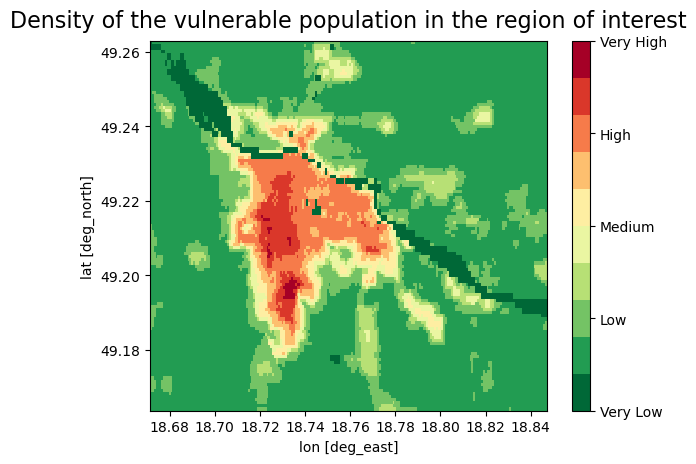

In [12]:
# Function to reclassify data using numpy
def reclassify_with_numpy_gt(array, bins, new_values):
    reclassified_array = np.zeros_like(array)
    reclassified_array[array <= bins[0]] = new_values[0]
    for i in range(len(bins) - 1):
        reclassified_array[(array > bins[i]) & (array <= bins[i + 1])] = new_values[i + 1]
    reclassified_array[array > bins[-1]] = new_values[-1]
    return reclassified_array

# Calculate the number of bins (classes)
num_bins = 9
# Equal interval classification
min_value = np.nanmin(pop)  # Minimum population value
max_value = np.nanmax(pop)  # Maximum population value
bin_width = (max_value - min_value) / num_bins  # Width of each bin
pop_bins = [min_value + i * bin_width for i in range(num_bins)]  # Define bin boundaries

# Define reclassification values
pop_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Apply the reclassification function to the population data
pop_class = reclassify_with_numpy_gt(pop.values, bins=pop_bins, new_values=pop_values)

# Convert the reclassified array back to xarray DataArray for plotting
pop_class_da = xr.DataArray(pop_class, coords=pop.coords, dims=pop.dims)

# Plot the data
fig, ax = plt.subplots()
cmap = plt.get_cmap('RdYlGn_r', 10) 
oa = pop_class_da.plot(ax=ax, cmap=cmap, add_colorbar=False)
cbar = fig.colorbar(oa, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'], size=10)
ax.set_xlabel('lon [deg_east]')
ax.set_ylabel('lat [deg_north]')
plt.title('Density of the vulnerable population in the region of interest', size=16, pad=10)
plt.show()

### Plot maps of the overheated areas next to the map of vulnerable population density

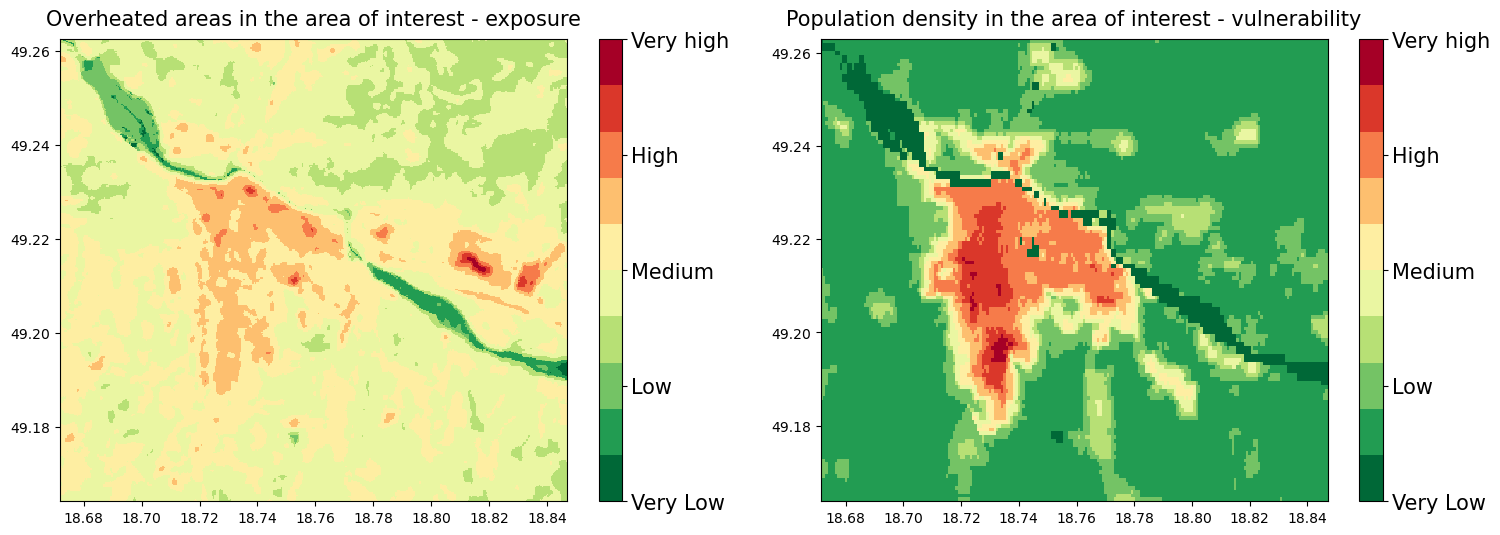

In [15]:
# This plots the overheated areas and population density maps
fig, axes=plt.subplots(ncols=2, figsize=(18,6))
cmap = plt.get_cmap('RdYlGn_r', 10) 
# Plot a data
oa1 = lc_class_da.plot(ax = axes[0], cmap=cmap, add_colorbar=False)
cbar = fig.colorbar(oa1, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels([ 'Very Low', 'Low', 'Medium', 'High', 'Very high'], size=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].set_title('Overheated areas in the area of interest - exposure', size=15, pad = 10)
# Plot a data
oa2 = pop_class_da.plot(ax = axes[1], cmap=cmap, add_colorbar=False)
cbar = fig.colorbar(oa2, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels([ 'Very Low', 'Low', 'Medium', 'High', 'Very high'], size=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_title('Population density in the area of interest - vulnerability', size=15, pad = 10)
plt.draw()

- On these plots we can see the most overheated areas together with the population density of the vulnerable groups of the population
- These maps were reclassified to the 10 groups, for the computation of the final Risk map based on the 10+10 risk matrix
- Risk matrix sum of the places that represent the greatest risk of  **exposure**  to high temperature and **vulnerable** population density (Very low group is the smallest because by sum we cannot get the value of 1)
- **The Risk matrix will be used in the next step for the estimation of the risk severity**

![heatwave ilustration](../images/risk_matrix_10to10.png?raw=true "Risk matrix example")

### Save data LST and population map

In [16]:
# This code saves the data to results_dir
lc_class_da.rio.to_raster(raster_path=f'{results_dir}/risk_LST.tif')
pop_class_da.rio.to_raster(raster_path=f'{results_dir}/risk_pop.tif')

## Calculate the heatwave risk map 

In this step we calculate the heatwave **risk** map based on the **exposure (LST - areas that heat up most)** x **vulnerability (density of vulnerable population)**. This risk map would then be based on historical data, and some interpretation is still needed to translate this result to future risk (see more information on this in the conclusions).

### Load data and create a raster stack

In [17]:
# This code creates a raster stack from risk_LST and risk_pop data, we need this step for the next processing of the data 
S2list = glob( f'{results_dir}/risk_*.tif')
#
with rasterio.open(S2list[0]) as src0:
    meta = src0.meta
#
meta.update(count = len(S2list))
#
with rasterio.open(f'{results_dir}/risk_raster_stack.tif', 'w', **meta) as dst:
    for id, layer in enumerate(S2list, start=1):
        with rasterio.open(layer) as src1:
            dst.write_band(id, src1.read(1))

### Calculate the risk 

We also loaded the vector layer of the critical places selected by Zilina City into the results. It is an example of how you can upload a map of the places you select as vulnerable places in your city based on your local knowledge and see if they are exposed to heat (places like hospitals, overcrowded places during the day, squares, etc.).

:::{note}

This requires preparing your own data for the analysis. Alternatively, you can proceed without your data by skipping this step.
:::

In [5]:
# This code loads the Critical infrastructure data, these data were created by the Zilina municipality office
ci=f'{data_dir}/ci_features_ZA.shp'
CI=gpd.read_file(ci)
CI_WGS=CI.to_crs(epsg=4326)

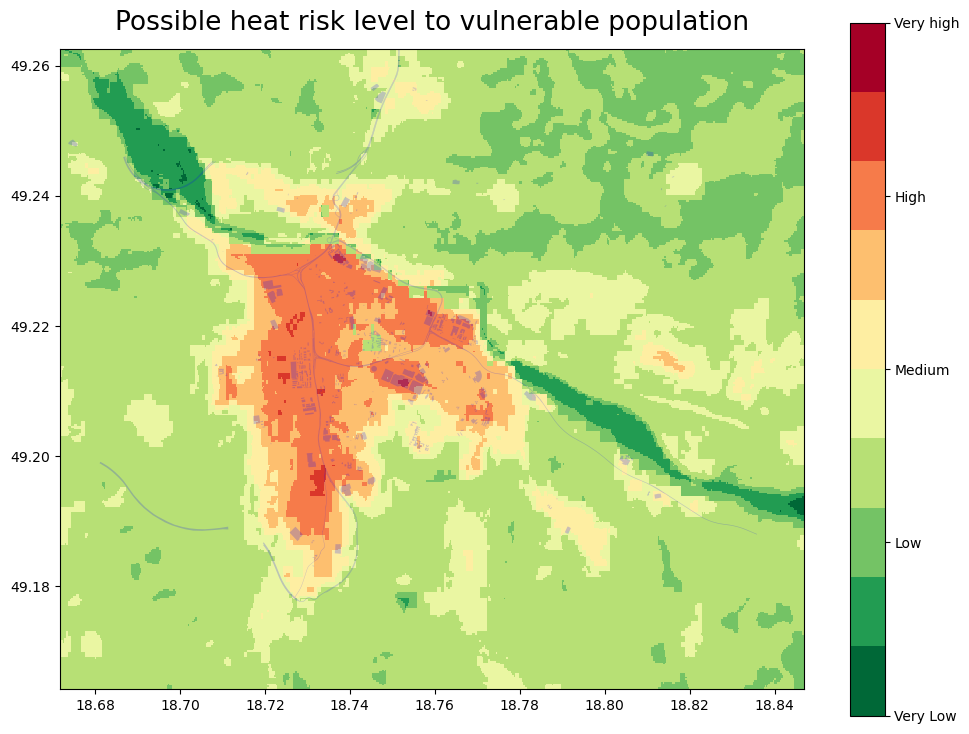

In [6]:
# This code calculates a risk map by multiplying a risk_LST and risk_pop data 
risk=f'{results_dir}/risk_raster_stack.tif'
risk = xr.open_dataset(risk)
risk=risk['band_data']
risk=(risk[0])+(risk[1])
# Plot a data
fig, ax = plt.subplots(figsize=(12, 9))

cmap = plt.get_cmap('RdYlGn_r', 10) 
oa3 = risk.plot(ax = ax, cmap=cmap, add_colorbar=False,vmin=1, vmax=20)
cbar = fig.colorbar(oa3, ticks=[1, 5.75, 10.5, 15.25, 20])
cbar.ax.set_yticklabels([ 'Very Low', 'Low', 'Medium', 'High', 'Very high'], size=10)
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Possible heat risk level to vulnerable population', size=19, pad = 14)

ci= CI_WGS.plot(ax=ax, color='blue', alpha=0.3)

**Based on the risk interpretation map (above), we can identify the places that can be most influenced by the heat (dark red) and are also populated with the vulnerable groups of the population, for better visualization, we can load a map with leafmap (below).**

### Save the risk map 

In [24]:
# This code saves the risk identification map in the results_dir
risk.rio.to_raster(raster_path=f'{results_dir}/Possible_heat_risk_level_to_vulnerable_population.tif')

### Plot Risk data on the interactive map

To see these maps on the interactive zoom in/out map with the Open Street Base map run the code below.

In [25]:
# This code creates a tile client from risk maps
# First, create a tile server from local raster file
riskpop = TileClient(f'{results_dir}/risk_pop.tif')
riskLST = TileClient(f'{results_dir}/risk_LST.tif')
HWRI = TileClient(f'{results_dir}/Possible_heat_risk_level_to_vulnerable_population.tif')

In [27]:
# This code creates ipyleaflet tile layer from that server
tpop = get_leaflet_tile_layer(riskpop, colormap='rdylgn_r', opacity=0.7, nodata=0, name='Risk population')
tLST = get_leaflet_tile_layer(riskLST, colormap='rdylgn_r', opacity=0.7, nodata=0, name='LST')
tHWRI = get_leaflet_tile_layer(HWRI, colormap='rdylgn_r', opacity=0.7, nodata=0, name='Possible_heat_risk_level')

In [30]:
# This code plots the results on the ipyleaflet map 

# Set the size of the map
map_layout = widgets.Layout(width='1100px', height='800px')

# This code plots all loaded rasters and vectors on the ipyleaflet map
m = Map(center=riskLST.center(), zoom=riskLST.default_zoom, layout=map_layout)

control = LayersControl(position='topright')

m.add(tpop)
m.add(tLST)
m.add(tHWRI)

labels = ["Very low", "Low", "Medium", "High", "Very High"]
colors = [(0, 104, 55), (35, 132, 67), (255, 255, 191), (255, 127, 0), (215, 25, 28)]

# Create legend HTML content with custom styles (smaller size)
legend_html = "<div style='position: absolute; bottom: 2px; left: 2px; padding: 10px; " \
              "background-color: #FFF; border-radius: 10px; box-shadow: 2px 2px 2px rgba(0,0,0,0.5); " \
              "width: 75px; height: 205px; '>"

# Append legend items (labels with colored markers)
for label, color in zip(labels, colors):
    color_hex = '#%02x%02x%02x' % color  # Convert RGB tuple to hex color
    legend_html += f"<p style='font-family: Arial, sans-serif; font-size: 14px; '>" \
                   f"<i style='background: {color_hex}; width: 10px; height: 10px; display: inline-block;'></i> {label}</p>"

legend_html += "</div>"

# Create a custom widget with the legend HTML
legend_widget = widgets.HTML(value=legend_html)

legend_control = WidgetControl(widget=legend_widget, position='bottomleft')
m.add_control(legend_control)

m.add(control)

m

Map(center=[49.2133495, 18.759248499999998], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

**How to use the map**: You can add or remove a map by "click" on the "layer control" in the top right corner, or "Zoom in/out" by "click" on the [+]/[-] in the top left corner 
We recommend first unclicking all the maps and then displaying them one by one, the transparency of the maps allows you to see which areas on the OpenStreetMap are most exposed to the heat, and in combination with the distribution of the vulnerable population, you can identify which areas should be prioritized for the application of the heat mitigation measures.

## Conclusion for the Risk identification results

The results of the risk workflow help you identify the places that are the most exposed to the effects of heat in combination with the map of areas with high density of vulnerable groups of population (based on age).

Together with the results of the Hazard assessment workflow **(example for the Zilina city in the picture below)** that gives you the information about the **probability of the heatwave occurrence** in the future, gives you a picture of the heatwave-connected problems in your selected area.

:::{note}

To generate such a graph for your own location please go to the hazard assessment workflow (e.g. EuroHEAT methodology found [here](heatwave_hazard_assessment_euroheat.ipynb)).
:::

![Heat-wave ilustration](../images/hw_occurence_Zilina_euroheat.png?raw=true "Heatwave occurence example")

:::{important}

There are important limitations to this analysis, associated with the source datasets:

- The Land surface temperature data is derived from the Landsat 8 satellite imagery and data of acceptable quality (without cloud cover) is only available for a limited number of days. That means that we get limited information on the maximum LST (past heatwaves are not always captured in the images from Landsat8). The resolution of the 30x30m also has its limitations, especially in the densely built-up areas.
- The world population data are available for 2020, and the distribution of the population may have changed (and will continue to change). Moreover, WorldPop data is based on modelling of populations distributions and not on local census data, therefore it may be inaccurate. Use of local data may help to reduce this uncertainty.
:::
 


## References

- Climate adapt (2021), [Apparent temperature heatwave days](https://climate-adapt.eea.europa.eu/en/metadata/indicators/apparent-temperature-heatwave-days) [2024-06-17].
- Climate adapt (2021), [Tropical nights](https://climate-adapt.eea.europa.eu/en/metadata/indicators/tropical-nights) [2025-07-14].
- Climate adapt (2021), [High UTCI Days](https://climate-adapt.eea.europa.eu/en/metadata/indicators/high-utci-days) [2024-06-17].
- European Space Agency ESA (2013), [Landsat 8 satellite imagery](https://earth.esa.int/eogateway/catalog/landsat-8-collection-2-european-coverage) [2024-06-20]
- Utah Space University (2024), [Difference between Air and surface temperature](https://caas.usu.edu/weather/graphical-data/surface-temperature) [2024-06-20]
- United States Environmental Protection Agency EPA (2024), [Heat Island Effect](https://www.epa.gov/heatislands) [2024-06-20]
- Nazarian, N., Krayenhoff, E. S., Bechtel, B., Hondula, D. M., Paolini, R., Vanos, J., Cheung, T., Chow, W. T. L., de Dear, R., Jay, O., Lee, J. K. W., Martilli, A., Middel, A., Norford, L. K., Sadeghi, M., Schiavon, S., Santamouris, M. (2022), Integrated Assessment of Urban Overheating Impacts on Human Life, Earth’s Future, 10(9). https://doi.org/10.1029/2022EF002682
- Parastatidis D, Mitraka Z, Chrysoulakis N, Abrams M. Online Global Land Surface Temperature Estimation from Landsat. Remote Sensing. (2017); 9(12):1208. https://doi.org/10.3390/rs9121208
- RSLAB, [Land surface temperature, based on the Landsat8 imagery](https://rslab.gr/Landsat_LST.html) [2024-06-20]

## Authors 

- Martin Kuban, KAJO services (martin.kuban@kajoservices.com)
- Milan Kalas, KAJO services (milan.kalas@kajoservices.com)
- Milica Aleksic, KAJO services (milica.aleksic@kajoservices.com)
- Natalia Aleksandrova, Deltares (review and editing)